# Generar graficas de resultados

- Generar tabla de diversidad de mutaciones

In [1]:
# Importar librerias necesarias

import pandas as pd # pandas
import matplotlib.pyplot as plt # matplotlib

In [2]:
# Cargar df
df = (
    pd.read_csv(
        "/Users/saitamawick98/bombas_de_eflujo/datos/SIFT_dis_sis.csv",
    )
)

In [3]:
# Visualizar tabla
df

,Tipo,SRA,Linaje,Sublinaje,Familia,Pais,SIFT_PREDICTION,GENE_ID,POS,REF_ALLELE,...,GENE_NAME,VARIANT_TYPE,REF_AMINO,ALT_AMINO,AMINO_POS,SIFT_SCORE,SIFT_MEDIAN,NUM_SEQS,Drtype,Mutacion
0,Discrepante,ERR2510876,L2,L2.2.1,Beijing,Italy,TOLERATED,Rv0191,222925,G,...,NaN,NONSYNONYMOUS,A,T,213.0,0.452,3.45,8.0,MDR-TB,Rv0191 A213T
1,Discrepante,ERR2510876,L2,L2.2.1,Beijing,Italy,TOLERATED,Rv0194,227098,T,...,NaN,NONSYNONYMOUS,M,T,74.0,1.000,2.92,49.0,MDR-TB,Rv0194 M74T
2,Discrepante,ERR2510876,L2,L2.2.1,Beijing,Italy,DELETERIOUS,Rv0194,230170,C,...,NaN,NONSYNONYMOUS,P,L,1098.0,0.002,2.91,60.0,MDR-TB,Rv0194 P1098L
3,Discrepante,ERR2510876,L2,L2.2.1,Beijing,Italy,TOLERATED,Rv0450c,541201,A,...,mmpL4,SYNONYMOUS,L,L,97.0,1.000,2.70,113.0,MDR-TB,mmpL4 L97L
4,Discrepante,ERR2510876,L2,L2.2.1,Beijing,Italy,TOLERATED,Rv0507,597816,A,...,mmpL2,SYNONYMOUS,A,A,206.0,0.482,2.68,112.0,MDR-TB,mmpL2 A206A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29511,Susceptible,ERR400454,L3,L3,CAS1-Delhi,NaN,TOLERATED,Rv2688c,3005185,G,...,NaN,NONSYNONYMOUS,P,T,156.0,0.839,2.70,54.0,NaN,Rv2688c P156T
29512,Susceptible,ERR400454,L3,L3,CAS1-Delhi,NaN,TOLERATED,Rv2936,3273107,C,...,drrA,SYNONYMOUS,A,A,298.0,0.786,2.61,91.0,NaN,drrA A298A
29513,Susceptible,ERR400454,L3,L3,CAS1-Delhi,NaN,TOLERATED,Rv3239c,3614982,T,...,NaN,SYNONYMOUS,L,L,874.0,1.000,3.50,19.0,NaN,Rv3239c L874L
29514,Susceptible,ERR400454,L3,L3,CAS1-Delhi,NaN,TOLERATED,Rv3728,4175354,A,...,NaN,NONSYNONYMOUS,E,A,161.0,1.000,3.66,8.0,NaN,Rv3728 E161A


In [4]:
# Crear columna de mutaciones encontradas
df["Mutacion"] = (
    df["GENE_NAME"].fillna(df["GENE_ID"]).astype(str) + " " +
    df["REF_AMINO"].fillna(df["REF_ALLELE"]).astype(str) +
    df["AMINO_POS"].fillna(df["POS"]).astype("Int64").astype(str) +
    df["ALT_AMINO"].fillna(df["ALT_ALLELE"]).astype(str)
)

In [5]:
# Separamos las columnas de gen y mutacion
df[["Gen", "Mut"]] = df["Mutacion"].str.split(" ", n=1, expand=True)

In [ ]:
# Agrupar por tipo y gen, contando el número de mutaciones únicas 
mut = df.groupby(["Tipo", "Gen"])["Mut"].nunique().reset_index().pivot_table(
    index="Gen", columns="Tipo", values="Mut", fill_value=0, aggfunc=lambda x: int(x)
).sort_values(by=["Discrepante", "Susceptible"], ascending=[False, True])

/var/folders/8s/0zjwys_9585g_ct_14ccvp9r0000gn/T/ipykernel_20392/2710826129.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  index="Gen", columns="Tipo", values="Mut", fill_value=0, aggfunc=lambda x: int(x)


In [27]:
mut

Tipo,Discrepante,Susceptible
Gen,,
Rv0194,72,80
mmpL8,65,82
mmpL2,63,66
Rv3239c,61,57
Rv3728,54,72
efpA,52,20
Rv1257c,51,24
mmpL5,48,70
Rv1217c,47,40


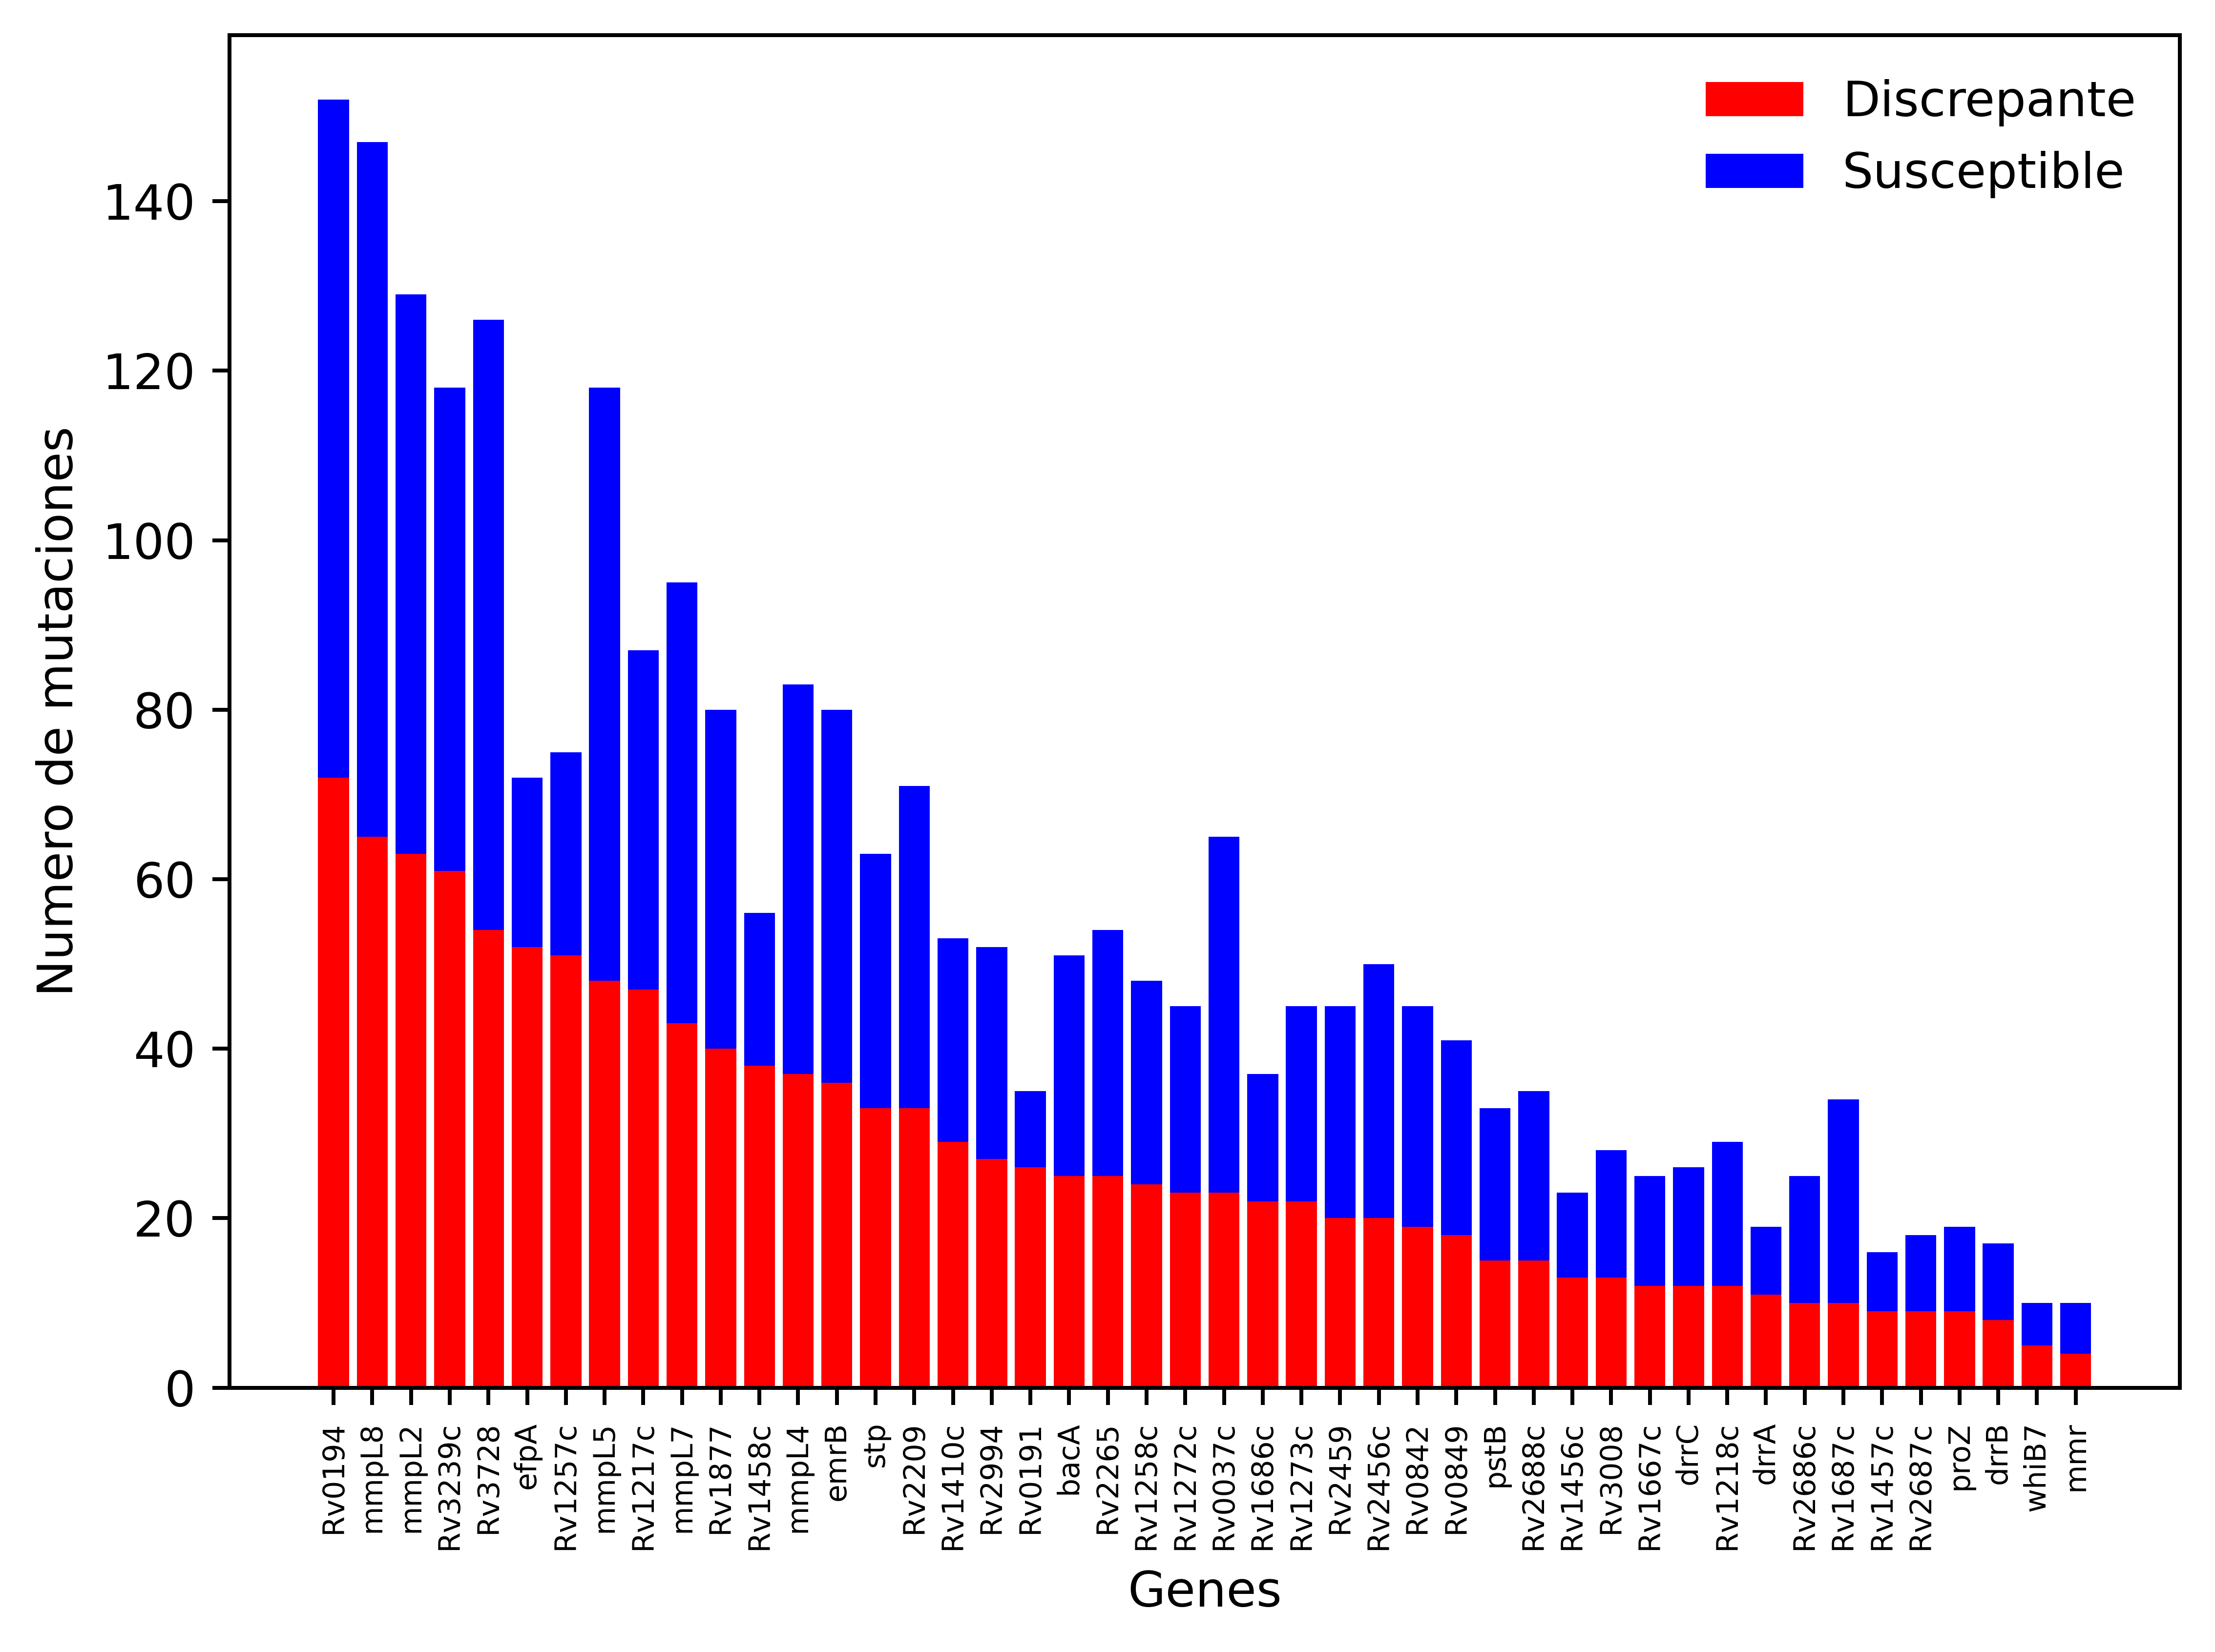

In [ ]:
fig, ax = plt.subplots(dpi=720)
fig.patch.set_alpha(0)   # fondo de toda la figura
ax.set_facecolor("none") # fondo del área de la gráfica

ax.bar(mut.index, mut["Discrepante"], label="Discrepante", color="red")
ax.bar(mut.index, mut["Susceptible"], label="Susceptible", color="blue", bottom=mut["Discrepante"])

# girar etiquetas del eje x
for label in ax.get_xticklabels():
    label.set_rotation(90)
    label.set_ha("center")
    label.set_fontsize(6)

ax.set_xlabel("Genes")
ax.set_ylabel("Numero de mutaciones")

# Agregar leyenda y eliminar contorno
ax.legend(frameon=False)

plt.tight_layout()